In [1]:
!pip uninstall jax jaxlib optax diffrax jaxtyping equinox dynamiqs -y
!pip install --upgrade "jax==0.6.2" "jaxlib==0.6.2" "jax-cuda12-plugin==0.6.2" "jax-cuda12-pjrt==0.6.2" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
!pip install -U dynamiqs

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: optax 0.2.8
Uninstalling optax-0.2.8:
  Successfully uninstalled optax-0.2.8
Looking in links: https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 64.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 MB 19.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 80.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 MB 14.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.7.2
    Uninstalling jax-cuda12-pjrt-0.7.2:
      Successfully uninstalled jax-cuda12-pjrt-0.7.2
  Attempting uninstall: jax-cuda12-plugin
    Found existi

In [2]:
import dynamiqs as dq
import jax.numpy as jnp
import matplotlib.pyplot as plt
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
dq.plot.mplstyle(dpi=150)  # set custom matplotlib style

print(device)

cuda


In [3]:
# initial state
psi0 = dq.fock(2, 0)

# Hamiltonian
delta = 0.3  # detuning
Omega = 1.0  # Rabi frequency
H = delta * dq.sigmaz() + Omega * dq.sigmax()

print(f"State of type {type(psi0)} and shape {psi0.shape}.")
print(f"Hamiltonian of type {type(H)} and shape {H.shape}.")

State of type <class 'dynamiqs.qarrays.dense_qarray.DenseQArray'> and shape (2, 1).
Hamiltonian of type <class 'dynamiqs.qarrays.sparsedia_qarray.SparseDIAQArray'> and shape (2, 2).


In [4]:
# define sampling times
sim_time = 10.0  # total time of evolution
num_save = 1001  # number of time slots to save
tsave = jnp.linspace(0.0, sim_time, num_save)  # can also be a list or a NumPy array

# define list of observables
exp_ops = [dq.sigmaz()]  # expectation value of sigma_z

# define method (Dormand-Prince method of order 5)
method = dq.method.Dopri5(rtol=1e-6, atol=1e-8)

In [5]:
# run simulation
result = dq.sesolve(H, psi0, tsave, exp_ops=exp_ops, method=method)

# print some information
print(f"`result` is of type {type(result)}.")
print(f"`result` has the following attributes:")
print(f"{[attr for attr in dir(result) if not attr.startswith('__')]}\n")
print(result)

|██████████| 100.0% ◆ elapsed 57.41ms ◆ remaining 0.00ms

`result` is of type <class 'dynamiqs.result.SESolveResult'>.
`result` has the following attributes:
['_abc_impl', '_saved', '_str_parts', 'block_until_ready', 'expects', 'extra', 'final_state', 'gradient', 'infos', 'method', 'options', 'out_axes', 'states', 'to_numpy', 'to_qutip', 'tsave']

==== SESolveResult ====
Method  : Dopri5
Infos   : 56 steps (48 accepted, 8 rejected)
States  : QArray complex64 (1001, 2, 1) | 15.6 Kb
Expects : Array complex64 (1, 1001) | 7.8 Kb


In [6]:
H = torch.tensor(H.to_numpy()).to(device)


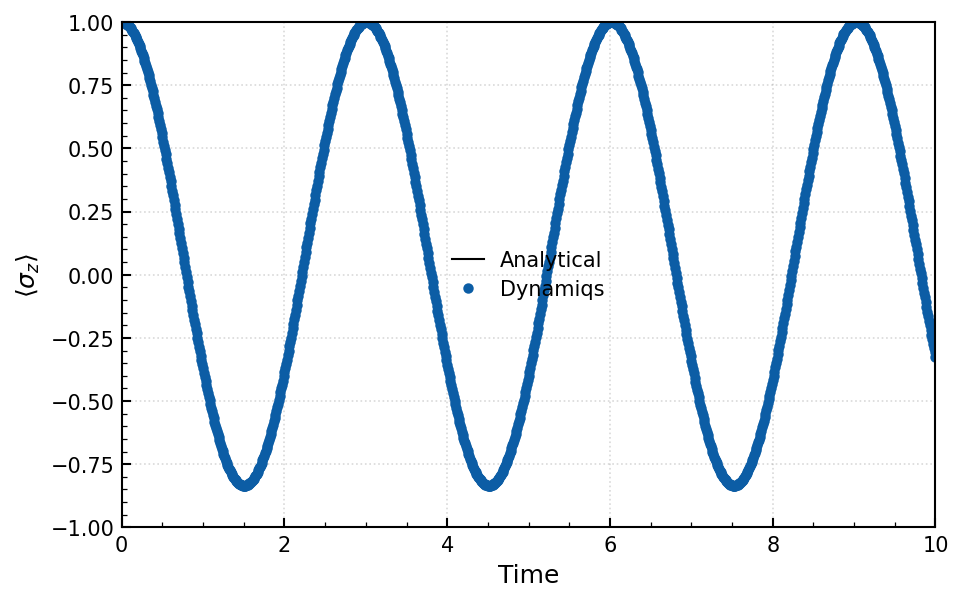

In [7]:
# analytical result
Omega_star = jnp.sqrt(delta**2 + Omega**2)  # generalized Rabi frequency
excited_pop = Omega / Omega_star * jnp.sin(tsave * Omega_star)  # excited population
sigmaz_analytical = 1 - 2 * excited_pop**2  # expectation value of sigma_z

# plot results
plt.plot(tsave, sigmaz_analytical, 'k', lw=1.0)
plt.plot(tsave, result.expects[0].real, 'oC0', ms=4)

# formatting
plt.xlabel('Time')
plt.ylabel(r'$\langle \sigma_z \rangle$')
plt.xlim(0, 10)
plt.ylim(-1, 1)
plt.legend(('Analytical', 'Dynamiqs'))

**`Forward simulation`**

In [8]:
from torch.utils.data import Dataset , DataLoader , Sampler



class RabiDataset(Dataset):
  def __init__(self,T,SigmaZ,device):
    super().__init__()
    self.T = T
    self.SigmaZ = SigmaZ
    self.residuals = torch.ones_like(self.T).to(device)

  def __len__(self):
    return len(self.T)

  def __getitem__(self, index) :
    return index,self.T[index],self.SigmaZ[index]


In [9]:
class AdaptiveResidualSampler(Sampler):
  def __init__(self,dataset):
    super().__init__()
    self.dataset = dataset


  def __iter__(self):
    porbabilities = torch.nn.functional.softmax(self.dataset.residuals)
    indecies = torch.multinomial(porbabilities, num_samples=len(self.dataset), replacement=False)
    return iter(indecies)

  def __len__(self):
    len(self.dataset)

In [10]:
import numpy as np
T = torch.from_numpy(np.array(tsave, copy=True))
SigmaZ = torch.from_numpy(np.array(result.expects[0].real, copy=True))
T_train , T_test = T , T
SigmaZ_train , SigmaZ_test = SigmaZ , SigmaZ

train_data = RabiDataset(T_train , SigmaZ_train,device)
test_data = RabiDataset(T_test , SigmaZ_test,device)

sampler = AdaptiveResidualSampler(train_data)



In [11]:
batch_size = 128
lr = 1e-3
train_loader = DataLoader(train_data,batch_size,sampler=sampler)
test_loader = DataLoader(test_data , 1001)
print(next(iter(train_loader))[0].shape)

/tmp/ipykernel_59/2814703387.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  porbabilities = torch.nn.functional.softmax(self.dataset.residuals)


torch.Size([128])


In [12]:
import torch.nn as nn
from torch.func import jacrev,vmap

class Pinn(nn.Module):
  def __init__(self,layers) :
    super().__init__()
    self.model = nn.Sequential()
    for i in range(len(layers)-1):
      self.model.add_module(f"Linear{str(i)}" , nn.Linear(layers[i] , layers[i+1]))
      self.model.add_module(f"activation{str(i)}" , nn.Tanh())
    self.model.add_module(f"output" , nn.Linear(layers[-1] , 4))

  def forward(self,x):
    return self.model(x)

In [13]:
def sigreg_weak_loss(x, sketch_dim=64):
    """
    Forces Covariance(x) ~ Identity.
    Matches the 2nd Moment (Spherical Cloud).
    """
    N, C = x.size()
    # 1. Sketching (Optional for C=512, but good for consistency)
    if C > sketch_dim:
        S = torch.randn(sketch_dim, C, device=x.device) / (C ** 0.5)
        x = x @ S.T  # [N, sketch_dim]
    else:
        sketch_dim = C

    # 2. Centering & Covariance
    x = x - x.mean(dim=0, keepdim=True)
    cov = (x.T @ x) / (N - 1 + 1e-6)

    # 3. Target Identity
    target = torch.eye(sketch_dim, device=x.device)

    # 4. Off-diagonal suppression + Diagonal maintenance
    return torch.norm(cov - target, p='fro')

In [14]:
model = Pinn([1,10,20,]).to(device)

optimizer = torch.optim.Adam(params=model.parameters() , lr = lr)
print(H)


def calc_forward(x):
  return model(x)

calc_jacobian = jacrev(calc_forward)
imaginary_vector = torch.tensor([1.0,1.0,1.0j,1.0j]).unsqueeze(1).to(device)

def calculate_derveative(x):
  derevatives = vmap(calc_jacobian)(x)
  derevatives =  derevatives*imaginary_vector
  d_psi = derevatives[:,[0,1],:] + derevatives[:,[2,3],:]


  return d_psi.squeeze()

def pde_resiual(i,psi,d_psi,H):
  psi = psi.unsqueeze(-1)*imaginary_vector
  psi = psi[:,[0,1]] + psi[:,[2,3]]
  psi = psi.squeeze()

  residual = torch.tensor([1.0j]).unsqueeze(1).to(device) * d_psi - psi @ H.T.to(torch.complex64).to(device)
  residual = torch.linalg.norm(residual , dim = 1)
  train_data.residuals[i] = residual
  residual = residual.mean()
  return residual
def boundary_loss():
  boundary = torch.tensor([0.0]).unsqueeze(1).to(device)
  state = model(boundary).unsqueeze(-1)*imaginary_vector
  state = state[:,[0,1]] + state[:,[2,3]]

  loss = torch.linalg.norm(state , dim = 0 ) **2
  loss = torch.nn.functional.mse_loss(loss[0] , torch.tensor([1.0]).to(device)) + torch.nn.functional.mse_loss(loss[1] , torch.tensor([0.0]).to(device))
  return loss

def norm_loss(psi):
  psi = psi.unsqueeze(-1)
  psi = psi * imaginary_vector
  psi = psi[:,[0,1],:] + psi[:,[2,3],:]
  psi = torch.linalg.norm(psi,dim = -1)**2
  sum = torch.sum(psi ,dim = -1)
  loss = torch.nn.functional.mse_loss(sum , torch.ones_like(sum))
  return loss


tensor([[ 0.3000+0.j,  1.0000+0.j],
        [ 1.0000+0.j, -0.3000+0.j]], device='cuda:0')


In [15]:

model = Pinn([1,5,10,]).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_params:,}")
optimizer = torch.optim.Adam(params=model.parameters() , lr = lr)

def train_step(i,model , optim , batch ,print_loss):
  model.train()
  optim.zero_grad()
  psi = model(batch).requires_grad_(True)

  d_psi = calculate_derveative(batch)

  loss =   0.6 * norm_loss(psi) + boundary_loss() + pde_resiual(i,psi,d_psi,H)
  loss.backward()
  if print_loss:
    print(f"psi shape {psi.shape}")
    print(loss)
  optim.step()


def test_step(model , batch):
  model.eval()
  psi = model(batch)
  d_psi = calculate_derveative(batch)

  loss = 0.1*norm_loss(psi) + 0.3*boundary_loss() + 0.3*pde_resiual(psi,d_psi,H)
  psi = psi.unsqueeze(-1)
  psi = psi * imaginary_vector
  psi = psi[:,[0,1],:] + psi[:,[2,3],:]
  psi = torch.linalg.norm(psi,dim = -1)**2




  sm = torch.nn.functional.softmax(psi , dim=-1)
  return psi[: , 0]   - psi[: , 1]

for j in range(5000):
  for i ,t , y in train_loader:
    print_loss = False
    if j%1000 == 0:
      print_loss = True
    train_step(i,model,optimizer , t.unsqueeze(1).to(device).requires_grad_(True),print_loss)
    #print(t.grad)

Parameters: 114


/tmp/ipykernel_59/2814703387.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  porbabilities = torch.nn.functional.softmax(self.dataset.residuals)
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


psi shape torch.Size([128, 4])
tensor(2.0087, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(2.0130, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.9916, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.9774, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.9643, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.9532, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.9359, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([105, 4])
tensor(1.9234, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.2809, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.3063, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.2910, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.296

tensor([0.9584, 0.9639, 0.9692,  ..., 0.1741, 0.1543, 0.1344], device='cuda:0',
       grad_fn=<SubBackward0>)


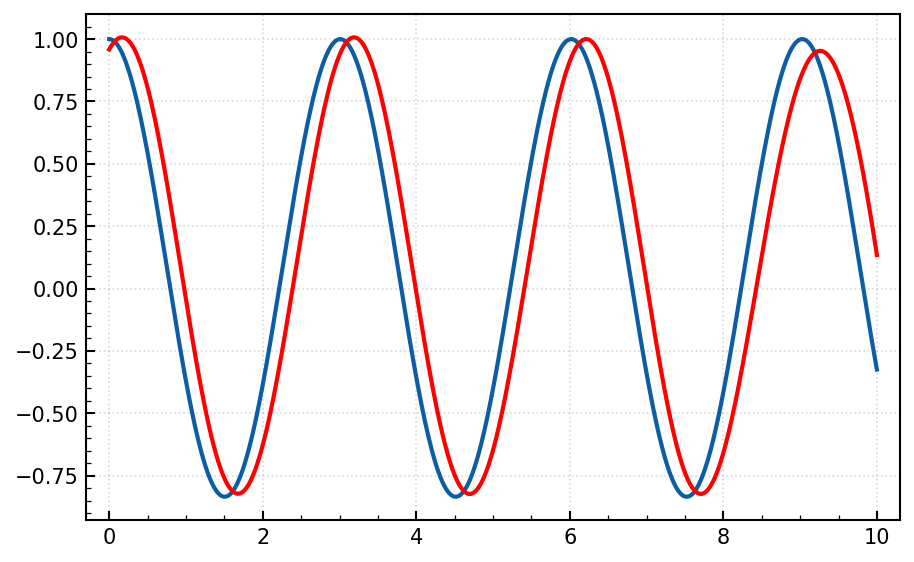

In [16]:
def test_step(i,model , batch):
  model.eval()
  batch = batch.to(device)
  psi = model(batch)
  d_psi = calculate_derveative(batch)

  loss = 0.1*norm_loss(psi) + 0.3*boundary_loss() + 0.3*pde_resiual(i,psi,d_psi,H)
  psi = psi.unsqueeze(-1)
  psi = psi * imaginary_vector
  psi = psi[:,[0,1],:] + psi[:,[2,3],:]
  psi = torch.linalg.norm(psi,dim = -1)**2
  sm = torch.nn.functional.softmax(psi , dim=-1)
  return psi[: , 0]   - psi[: , 1]
for i,t , y in test_loader:

  sigma_z = test_step(i,model , t.unsqueeze(1))

  print(sigma_z)
plt.plot(t,y)
plt.plot(t.cpu(),sigma_z.detach().cpu(),"r")


**Inverse for the hamiltonian's parameters
**

In [ ]:

model = Pinn([1,10,20,]).to(device)
class Paramerizer(nn.Module):
  def __init__(self):
    super().__init__()
    self._model = nn.Sequential(nn.Linear(1,8) , nn.Tanh() , nn.Linear(8,14), nn.Tanh() , nn.Linear(14,2))

  def forward(self,x):
    return self._model(x)

parametrize = Paramerizer().to(device)

sigmaz = torch.from_numpy(np.array(dq.sigmaz(), copy=True)).to(device)
sigmax = torch.from_numpy(np.array(dq.sigmax(), copy=True)).to(device)

print(H)


def calc_forward(x):
  return model(x)

calc_jacobian = jacrev(calc_forward)
imaginary_vector = torch.tensor([1.0,1.0,1.0j,1.0j]).unsqueeze(1).to(device)

def calculate_derveative(x):
  derevatives = vmap(calc_jacobian)(x)
  derevatives =  derevatives*imaginary_vector
  d_psi = derevatives[:,[0,1],:] + derevatives[:,[2,3],:]


  return d_psi.squeeze()

def pde_resiual(i,psi,d_psi,H):
  psi = psi.unsqueeze(-1)*imaginary_vector
  psi = psi[:,[0,1]] + psi[:,[2,3]]
  psi = psi.squeeze()

  residual = torch.tensor([1.0j]).unsqueeze(1).to(device) * d_psi - psi @ H.T.to(torch.complex64).to(device)
  residual = torch.linalg.norm(residual , dim = 1)
  train_data.residuals[i] = residual
  residual = residual.mean()
  return residual
def boundary_loss(boundary , y):
  boundary = boundary.to(device)
  state = model(boundary).unsqueeze(-1)*imaginary_vector
  state = state[:,[0,1]] + state[:,[2,3]]
  loss = state.real ** 2 + state.imag ** 2
  loss = loss.squeeze()  
  
  loss = torch.nn.functional.mse_loss(loss[...,0] -loss[...,1] , y)
  return loss

def norm_loss(psi):
  psi = psi.unsqueeze(-1)
  psi = psi * imaginary_vector
  psi = psi[:,[0,1],:] + psi[:,[2,3],:]
  psi = torch.linalg.norm(psi,dim = -1)**2
  sum = torch.sum(psi ,dim = -1)
  loss = torch.nn.functional.mse_loss(sum , torch.ones_like(sum))
  return loss

model = Pinn([1,5,10,]).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {num_params:,}")

optimizer = torch.optim.Adam(params=list(model.parameters())+list(parametrize.parameters()) , lr = lr)

def train_step(i,model,parametrizer , optim , batch ,y,print_loss):
  model.train()
  optim.zero_grad()
  psi = model(batch).requires_grad_(True)
  params = parametrizer(batch)
  
  H = params[...,0][:,None,None] * sigmaz + params[...,1][:,None,None] * sigmax
  H = H.mean(dim = 0)
  d_psi = calculate_derveative(batch)

  loss =  0.6 * norm_loss(psi) + 2*boundary_loss(batch,y) + pde_resiual(i,psi,d_psi,H)
  loss.backward()
  if print_loss:
    print(f"psi shape {psi.shape}")
    print(loss)
  optim.step()


def test_step(model , batch):
  model.eval()
  psi = model(batch)
  d_psi = calculate_derveative(batch)

  loss = 0.1*norm_loss(psi) + 0.3*boundary_loss() + 0.3*pde_resiual(psi,d_psi,H)
  psi = psi.unsqueeze(-1)
  psi = psi * imaginary_vector
  psi = psi[:,[0,1],:] + psi[:,[2,3],:]
  psi = torch.linalg.norm(psi,dim = -1)**2




  sm = torch.nn.functional.softmax(psi , dim=-1)
  return psi[: , 0]   - psi[: , 1]

for j in range(100000):
  for i ,t , y in train_loader:
    print_loss = False
    if j%1000 == 0:
      print_loss = True
    train_step(i,model,parametrize,optimizer , t.unsqueeze(1).to(device).requires_grad_(True),y.to(device),print_loss)
    #print(t.grad)

tensor([[ 0.3000+0.j,  1.0000+0.j],
        [ 1.0000+0.j, -0.3000+0.j]], device='cuda:0')
Parameters: 114
psi shape torch.Size([128, 4])
tensor(1.3573, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.3104, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.3643, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.4017, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.4829, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.4283, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(1.3524, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([105, 4])
tensor(1.4587, device='cuda:0', grad_fn=<AddBackward0>)


/tmp/ipykernel_59/2814703387.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  porbabilities = torch.nn.functional.softmax(self.dataset.residuals)


psi shape torch.Size([128, 4])
tensor(0.7644, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.7612, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.6706, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.7517, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.7317, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.7659, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.7009, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([105, 4])
tensor(0.8035, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.7604, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.6691, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.7268, device='cuda:0', grad_fn=<AddBackward0>)
psi shape torch.Size([128, 4])
tensor(0.670

tensor([0.3496, 0.3504, 0.3512,  ..., 0.3356, 0.3364, 0.3371], device='cuda:0',
       grad_fn=<SubBackward0>)


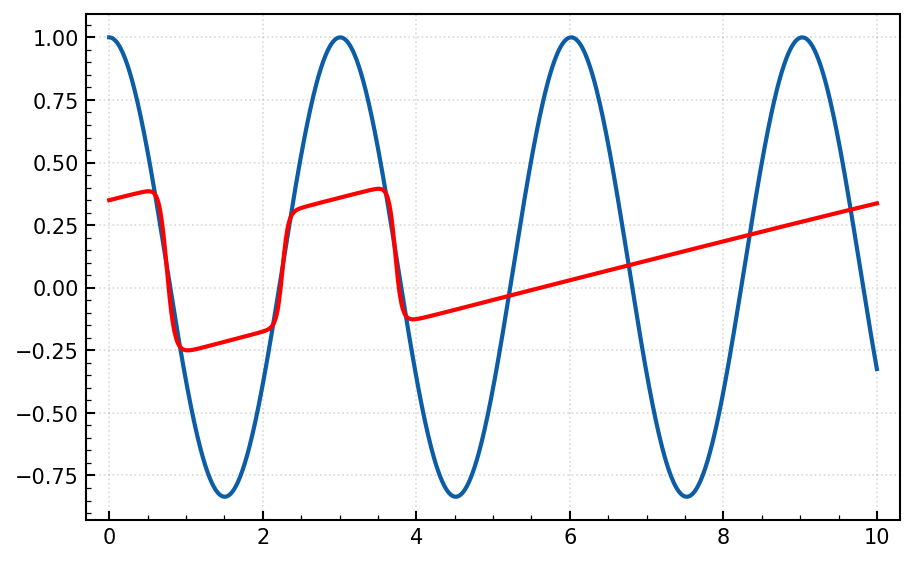

In [18]:
def test_step(i,model , batch):
  model.eval()
  batch = batch.to(device)
  psi = model(batch)
  d_psi = calculate_derveative(batch)

  #loss = 0.1*norm_loss(psi) + 0.3*boundary_loss() + 0.3*pde_resiual(i,psi,d_psi,H)
  psi = psi.unsqueeze(-1)
  psi = psi * imaginary_vector
  psi = psi[:,[0,1],:] + psi[:,[2,3],:]
  psi = torch.linalg.norm(psi,dim = -1)**2
  sm = torch.nn.functional.softmax(psi , dim=-1)
  return psi[: , 0]   - psi[: , 1]
for i,t , y in test_loader:

  sigma_z = test_step(i,model , t.unsqueeze(1))

  print(sigma_z)
plt.plot(t,y)
plt.plot(t.cpu(),sigma_z.detach().cpu(),"r")


In [ ]:
predicted_params = parametrize(torch.rand([1000,1]).to(device)).mean(0)

real_params = torch.tensor([delta,Omega])

print(f"real delta : {real_params[0]} , predicted delta {predicted_params[0]}")
print(f"real Omega : {real_params[1]} , predicted Omega {predicted_params[1]}")

print(f"absolute delta error: {real_params[0]-predicted_params[0]} ,absolute Omega error {real_params[1]-predicted_params[1]}")